In [1]:
! pip install nelson_siegel_svensson
! pip install yfinance
! pip install pandas_datareader

In [5]:
# =========================
# Standard Library
# =========================
import warnings
import datetime as dt

warnings.filterwarnings("ignore")

# =========================
# Core Scientific Stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Data Sources
# =========================
import yfinance as yf
from pandas_datareader import data as pdr

# =========================
# Statistics & Math
# =========================
from scipy.stats import norm, ncx2
from scipy.interpolate import LinearNDInterpolator
from scipy.optimize import minimize
from scipy.stats import lognorm

# =========================
# Machine Learning / Metrics
# =========================
from sklearn.metrics import mean_squared_error

# =========================
# Financial Models
# =========================
from nelson_siegel_svensson.calibrate import calibrate_ns_ols

# =========================
# Plotting
# =========================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# =========================
# Fetch + Clean Data
# =========================

def load_option_data(ticker):
    tk = yf.Ticker(ticker)

    try:
        maturities = tk.options
        if len(maturities) == 0:
            raise ValueError("No options found.")
    except:
        raise ValueError("Invalid ticker.")

    spot = yf.download(ticker, period="5d", auto_adjust= False)["Adj Close"].dropna().iloc[-1] # underlying current value of the stock we compute mark-to market

    all_calls = []

    for m in maturities:
        chain = tk.option_chain(m)
        calls = chain.calls.copy()
        calls["maturity"] = pd.to_datetime(m)
        all_calls.append(calls)

    df = pd.concat(all_calls, ignore_index=True)

    return float(spot), maturities, df

def clean_data(df, S0):
    today = pd.Timestamp.today().normalize()

    df["Time_to_Maturity"] = (df["maturity"] - today).dt.days / 365
    df["Option_Price"] = (df["bid"] + df["ask"]) / 2  # option price
    df["Moneyness"] = np.log(S0 / df["strike"])


    df = df[
        (df["bid"] > 0) &
        (df["ask"] > 0) &
        (df["Time_to_Maturity"] > 0.24) & # not too close nor to far in the future between three month to one year
        (df["Time_to_Maturity"] < 2.0) &
        (df["volume"].fillna(0) > 5) &
        (df['Moneyness']> -0.1 ) &    # Moneyness  # only consider options within a certain range of the current price , most options that are most traded
        (df['Moneyness']< 0.8) &
        (df['openInterest'] > 10) &
        (df['impliedVolatility'] > 0.05)
    ]

    return df[['impliedVolatility','Time_to_Maturity', 'Moneyness', 'strike', 'Option_Price']].dropna()

# =========================
# Fetch Treasury Yields
# =========================

def fetch_yield_curve():
    """
    Fetch US Treasury yields from FRED
    Returns maturities (years) and rates (decimal)
    """

    series = {
        "DGS1MO": 1/12,
        "DGS3MO": 3/12,
        "DGS6MO": 6/12,
        "DGS1": 1,
        "DGS2": 2,
        "DGS5": 5,
        "DGS10": 10
    }

    end = dt.datetime.today()
    start = end - dt.timedelta(days=10)

    data = {}

    for code, maturity in series.items():
        try:
            df = pdr.DataReader(code, "fred", start, end)
            value = df.dropna().iloc[-1, 0] / 100  # convert % → decimal
            data[maturity] = value
        except:
            continue

    # sort by maturity
    maturities = np.array(sorted(data.keys()))
    rates = np.array([data[m] for m in maturities])

    return maturities, rates

# =========================
# Interpolation
# =========================

def get_rate(T, maturities, rates):
    """
    Interpolate rate for maturity T

    """
    curve, status = calibrate_ns_ols(maturities, rates, tau0=1.0)
    return float(curve(T))

# =========================
# black_scholes_call
# =========================


def black_scholes_call(S, K, T, r, sigma):
    """
    :param S: Asset price
    :param K: Strike price
    :param T: Time to maturity
    :param r: risk-free rate (treasury bills)
    :param sigma: volatility
    :return: call price
    """
    N_prime = norm.pdf
    N = norm.cdf
    # Black-Scholes Formula
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S * N(d1) - N(d2) * K * np.exp(-r * T)
    return call

# =========================
# IV Surface Interpolation
# =========================

def build_iv_surface(df):
    points = list(zip(df['Moneyness'], df['Time_to_Maturity']))
    values = df['impliedVolatility']

    interp = LinearNDInterpolator(points, values)

    def iv(k, T):
        val = interp(k, T)
        if np.isnan(val):
            # fallback: nearest neighbor
            dist = (df['Moneyness']-k)**2 + (df['Time_to_Maturity']-T)**2
            return df.iloc[np.argmin(dist)]['impliedVolatility']
        return float(val)

    return iv

# =========================
# Plot IV Surface
# =========================

def plot_surface(df):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_trisurf(
        df['Moneyness'],
        df['Time_to_Maturity'],
        df['impliedVolatility']*100,
        cmap=plt.cm.viridis
    )

    ax.set_xlabel("Moneyness (log)")
    ax.set_ylabel("Maturity (T)")
    ax.set_zlabel("IV (%)")

    plt.show()


# =========================
# Local Volatility with callibration
# =========================

def C(S0, strike, T, r, sigma, beta):
  zb = 2 + 2/(2-beta)
  kappa = 2 *r/(sigma **2 * 2*(2-beta)* (np.exp(r*(2-beta)*T)-1))
  x = kappa * S0 ** (2-beta)*np.exp(r*(2-beta) * T)
  y = kappa * strike **(2-beta)
  return S0*(1-ncx2.cdf(2*y,zb,2*x)) - strike*np.exp(-r*T)*(ncx2.cdf(2*x,zb-2,2*y))

def calibrate_cev(df, S0, yc_mats, yc_rates):

    def error(params):
        sigma, beta = params

        model = []
        market = df['Option_Price'].values

        for _, row in df.iterrows():
            T = row['Time_to_Maturity']
            K = row['strike']
            r = get_rate(T, yc_mats, yc_rates)

            model.append(C(S0, K, T, r, sigma, beta))

        return mean_squared_error(market, model)

    res = minimize(
        error,
        x0=(0.5, 0.7),
        bounds=((0.01,2),(0,1.9)),
        method='L-BFGS-B'
    )

    return res


Enter ticker (e.g. ^SPX, AAPL): TSLA


[*********************100%***********************]  1 of 1 completed



Spot: 386.42
Options used: 148

Available maturities:
2026-04-24
2026-04-27
2026-04-29
2026-05-01
2026-05-04
2026-05-08
2026-05-15
2026-05-22
2026-05-29
2026-06-18
2026-07-17
2026-08-21
2026-09-18
2026-10-16
2026-11-20
2026-12-18
2027-01-15
2027-03-19
2027-06-17
2027-12-17
2028-01-21
2028-06-16
2028-12-15

Choose maturity: 2026-12-18
Curve:
0.08Y -> 3.6900%
0.25Y -> 3.7100%
0.50Y -> 3.7200%
1.00Y -> 3.6500%
2.00Y -> 3.7200%
5.00Y -> 3.8600%
10.00Y -> 4.2600%

Interpolated rate: 0.03644496912674157
Strike: 360


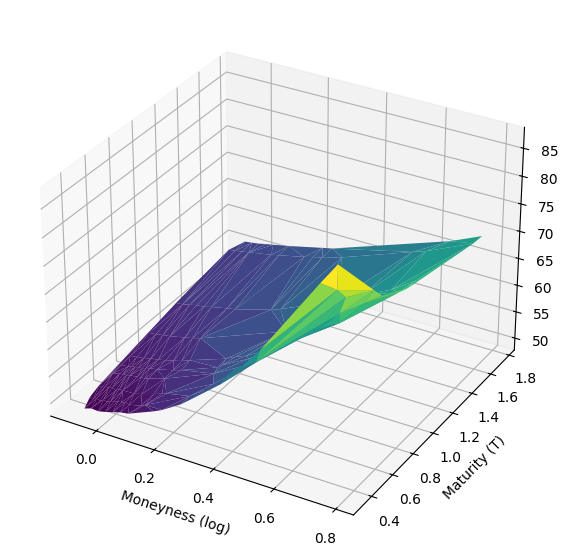


=== Black-Scholes ===
IV: 0.5243
Call: 81.2403
Put: 46.2608

=== Results Using Local Volatility===
Local Vol: 2.0000
Beta: 1.4165
Call Price: 78.7959
Put Price: 43.8164


In [4]:
# =========================
# MAIN
# =========================

def main():

# get the ticke
  ticker = input("Enter ticker (e.g. ^SPX, AAPL): ").strip()

  S0, maturities, raw = load_option_data(ticker)
  df = clean_data(raw, S0)

  print(f"\nSpot: {S0:.2f}")
  print(f"Options used: {len(df)}")

  print("\nAvailable maturities:")
  for m in maturities:
    print(m)

  maturity = input("\nChoose maturity: ").strip()
  if maturity not in maturities:
    print("Invalid maturity.")

  # compute T
  today = pd.Timestamp.today().normalize()
  T = (pd.to_datetime(maturity) - today).days / 365

  yc_mats, yc_rates = fetch_yield_curve()
  # build curve

  print("Curve:")
  for m, r in zip(yc_mats, yc_rates):
    print(f"{m:.2f}Y -> {r:.4%}")

  r= get_rate(T, yc_mats, yc_rates )
  print("\nInterpolated rate:", r)


  K = float(input("Strike: "))


  # plot surface
  plot_surface(df)

  # build IV surface
  iv_func = build_iv_surface(df)

  r = get_rate(T, yc_mats, yc_rates)
  k = np.log(S0 / K)

  sigma = iv_func(k, T)

  call = black_scholes_call(S0, K, T, r, sigma)
  put = call - S0 + K*np.exp(-r*T)

  print("\n=== Black-Scholes ===")
  print(f"IV: {sigma:.4f}")
  print(f"Call: {call:.4f}")
  print(f"Put: {put:.4f}")

  # CEV calibration
  res = calibrate_cev(df, S0, yc_mats, yc_rates)

  sigma_cev, beta = res.x

  cev_price = C(S0, K, T, r, sigma_cev, beta)
  put_local = cev_price - S0 + K*np.exp(-r*T)


  print("\n=== Results Using Local Volatility===")
  print(f"Local Vol: {res.x[0]:.4f}")
  print(f"Beta: {res.x[1]:.4f}")
  print(f"Call Price: {cev_price:.4f}")
  print(f"Put Price: {put_local:.4f}")



if __name__ == "__main__":
    main()